In [ ]:
# 돌리고 런타임 다시 시작해야 됨
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 16 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,216 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 120831 files and dire

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

In [4]:
df = pd.read_excel('../data_sample/한이음_base모델.xlsx')
df.head()

,시점,매매가격지수,금리,국내총생산,대출금리,매매 거래량
0,2021-01-01,84.207770,0.5,"484,679",2.63,"113,272"
1,2021-02-01,85.687847,0.5,"484,679",2.66,"107,119"
2,2021-03-01,87.170534,0.5,"484,679",2.73,"105,463"
3,2021-04-01,88.417382,0.5,"517,054.3",2.73,"111,192"
4,2021-05-01,89.526341,0.5,"517,054.3",2.69,"109,821"


### @title 상관관계 분석

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   시점      27 non-null     datetime64[ns]
 1   매매가격지수  27 non-null     float64       
 2   금리      27 non-null     float64       
 3   국내총생산   27 non-null     object        
 4   대출금리    27 non-null     float64       
 5   매매 거래량  27 non-null     object        
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 1.4+ KB


In [13]:
df['국내총생산'] = df['국내총생산'].str.replace(',', '').astype(float)
df['매매 거래량'] = df['매매 거래량'].str.replace(',', '').astype(float)

In [14]:
import warnings
warnings.filterwarnings('ignore')

### @title 정규화 & 모델 적합

In [15]:
df.set_index('시점', inplace=True)

In [16]:
df.head()

,매매가격지수,금리,국내총생산,대출금리,매매 거래량
시점,,,,,
2021-01-01,84.207770,0.5,484679.0,2.63,113272.0
2021-02-01,85.687847,0.5,484679.0,2.66,107119.0
2021-03-01,87.170534,0.5,484679.0,2.73,105463.0
2021-04-01,88.417382,0.5,517054.3,2.73,111192.0
2021-05-01,89.526341,0.5,517054.3,2.69,109821.0


In [17]:
train_df = df.query("시점 < '2022-08-01'")
valid_df = df.query("시점 >= '2022-05-01' and 시점 < '2022-11-01'")
test_df = df.query("시점 >= '2022-09-01' and 시점 <= '2023-03-01'")

In [18]:
train_df.tail()

,매매가격지수,금리,국내총생산,대출금리,매매 거래량
시점,,,,,
2022-03-01,100.266413,1.25,512012.9,3.84,62391.0
2022-04-01,100.460384,1.25,544239.8,3.90,74575.0
2022-05-01,100.711938,1.50,544239.8,3.90,63769.0
2022-06-01,100.752493,1.75,544239.8,4.04,60119.0
2022-07-01,100.677875,1.75,548892.5,4.16,42595.0


In [19]:
valid_df.head()

,매매가격지수,금리,국내총생산,대출금리,매매 거래량
시점,,,,,
2022-05-01,100.711938,1.50,544239.8,3.90,63769.0
2022-06-01,100.752493,1.75,544239.8,4.04,60119.0
2022-07-01,100.677875,1.75,548892.5,4.16,42595.0
2022-08-01,100.449869,2.25,548892.5,4.35,51007.0
2022-09-01,100.209062,2.50,548892.5,4.79,37727.0


In [20]:
test_df.head()

,매매가격지수,금리,국내총생산,대출금리,매매 거래량
시점,,,,,
2022-09-01,100.209062,2.50,548892.5,4.79,37727.0
2022-10-01,99.468871,2.50,556628.7,4.82,39369.0
2022-11-01,98.057422,3.00,556628.7,4.74,38186.0
2022-12-01,96.569873,3.25,556628.7,4.63,52385.0
2023-01-01,94.724287,3.25,523816.2,4.58,39124.0


In [21]:
# 데이터 scaling

from sklearn.preprocessing import MinMaxScaler

def preprocessing(df):
    timesteps = 3  # 시계열 예측 input 길이
    X = []          # 독립변수
    y = []          # 종속변수

    for i in range(timesteps, df.shape[0]):
        X.append(df[i - timesteps:i])
        y.append(df[i][0])  # Index 1 corresponds to "매매가격지수"

    X = np.array(X)
    y = np.array(y)

    return X, y

def scaling(df):
  scale = MinMaxScaler(feature_range=(0, 1))
  features = ['매매가격지수', '국내총생산', '대출금리', '매매 거래량']

  scaledDf = scale.fit_transform(df[features]) # 스케일링된 값

  addCol = np.array(df['금리'])
  addCol = addCol.reshape(-1, 1)

  result = np.hstack((scaledDf, addCol))

  return result

def reverse_scaling(org_x, x):
  org_x = np.asarray(org_x)
  x     = np.asarray(x)

  return (x * (org_x.max() - org_x.min() + 1e-7)) + org_x.min()

In [22]:
X_train, y_train = preprocessing(scaling(train_df))
X_val, y_val = preprocessing(scaling(valid_df))
X_test, y_test = preprocessing(scaling(test_df))

In [23]:
print(f'train X 길이 : {len(X_train)}, train y 길이 : {len(y_train)}')
print(f'val X 길이 : {len(X_val)}, val y 길이 : {len(y_val)}')
print(f'test X 길이 : {len(X_test)}, test y 길이 : {len(y_test)}')

train X 길이 : 16, train y 길이 : 16
val X 길이 : 3, val y 길이 : 3
test X 길이 : 4, test y 길이 : 4


In [ ]:
# Attention 설계

import tensorflow as tf
from keras.layers import *
from keras.models import *
from keras import backend as K

class Attention(Layer):
    # Insert **kwargs to __init__() function.
    def __init__(self, return_sequences=True, **kwargs):
        self.return_sequences = return_sequences

        super(Attention,self).__init__()

    def get_config(self):
        config = super().get_config()
        config.update({
            "return_sequences": self.return_sequences,
        })
        return config

    def build(self, input_shape):
        self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],1),
                               initializer="normal")
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],1),
                               initializer="normal")
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],1))
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],1))
        super(Attention,self).build(input_shape)

    def call(self, x):                         # Attention 가중치 계산
        e = K.tanh(K.dot(x,self.W)+self.b)
        a = K.softmax(e, axis=1)
        output = x*a
        if self.return_sequences:
          return output
        return K.sum(output, axis=1)

# 8개의 multihead-attention으로 구성
class MultiAttention(Layer):
  def __init__(self, n_heads):
    super(MultiAttention, self).__init__()
    self.n_heads = n_heads
    self.attn_heads = list()
    self.units = 8

  def build(self, input_shape):
    for n in range(self.n_heads):
      self.attn_heads.append(Attention(return_sequences=True))

    self.linear = Dense(self.units,
                        input_shape=input_shape,
                        kernel_initializer='glorot_uniform',
                        bias_initializer='glorot_uniform')

  def call(self, inputs):
    attn = [self.attn_heads[i](inputs) for i in range(self.n_heads)]
    concat_attn = tf.concat(attn, axis=-1)
    multi_linear = self.linear(concat_attn)
    return multi_linear

In [ ]:
from keras.models import Sequential, load_model
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error
from keras.layers import Flatten

In [ ]:
earlystop = EarlyStopping(monitor='val_loss', min_delta=0.0001, patience=5, verbose=1, mode='min', baseline=0.0001)
callbacks_list = [earlystop]
hl = [64, 32]
lr = 1e-3
batch_size = 64
epochs = 512

In [ ]:
model = Sequential()

model.add(LSTM(X_train.shape[2],input_shape = (X_train.shape[1],X_train.shape[2]),return_sequences = True,
                activation = 'relu'))

for i in range(len(hl)):
    model.add(LSTM(hl[i],activation = 'relu',return_sequences = True))

model.add(Dropout(0.2))

model.add(LSTM(hl[-1],activation = 'relu'))

model.add(Dense(1))

model.add(MultiAttention(n_heads=16))

model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')

In [ ]:
model.fit(X_train, y_train,
          epochs = epochs,
          batch_size = batch_size,
          validation_data = (X_val, y_val),
          verbose = 0,
          shuffle = False,
          callbacks=callbacks_list)

Epoch 43: early stopping


### @title 모델 예측

In [ ]:
y_hat = model.predict(X_test)

1/1 [==============================] - 0s 465ms/step


In [ ]:
y_hat = y_hat[-3:]

In [ ]:
df.tail(5)

,매매가격지수,금리,국내총생산,대출금리,매매 거래량
시점,,,,,
2022-11-01,98.057422,3.00,556628.7,4.74,38186.0
2022-12-01,96.569873,3.25,556628.7,4.63,52385.0
2023-01-01,94.724287,3.25,523816.2,4.58,39124.0
2023-02-01,93.626154,3.50,523816.2,4.56,63909.0
2023-03-01,92.481888,3.50,523816.2,4.40,59750.0


In [ ]:
predict = df.tail(3)
pre = pd.concat([predict], axis=0)
pre

,매매가격지수,금리,국내총생산,대출금리,매매 거래량
시점,,,,,
2023-01-01,94.724287,3.25,523816.2,4.58,39124.0
2023-02-01,93.626154,3.50,523816.2,4.56,63909.0
2023-03-01,92.481888,3.50,523816.2,4.40,59750.0


In [ ]:
Y_org = np.array(pre['매매가격지수'])
Y_test = reverse_scaling(Y_org, y_test[-3:])    # 실제값
Y_test

array([93.13262439, 92.81395008, 92.48188788])

In [ ]:
Y_hat = reverse_scaling(Y_org, y_hat)
Y_hat

array([[94.199585],
       [94.130486],
       [94.04049 ]], dtype=float32)

In [ ]:
Y_hat = np.concatenate(Y_hat).tolist()
Y_hat = np.array(Y_hat)    # 모델 예측값
Y_hat

array([94.19958496, 94.13048553, 94.0404892 ])

In [ ]:
from math import sqrt

mse = mean_squared_error(y_test[-3:], y_hat)
rmse = sqrt(mse)

print(f'MSE = {mse}')
print(f'RMSE = {rmse}')

MSE = 0.3514018230306344
RMSE = 0.5927915510789896


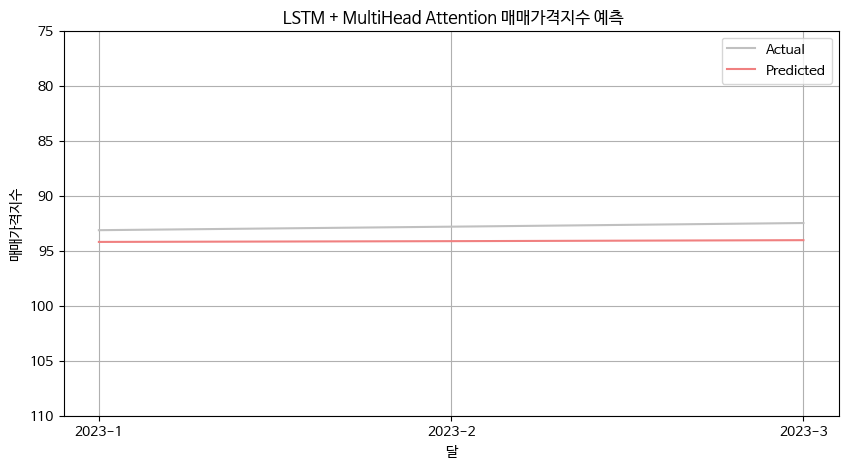

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 10
minPrice = 75
maxPrice = 110

plt.figure(figsize = (10, 5))
plt.plot(Y_test, c = 'silver') # 위에서 실제 Open price 역스케일한 값
plt.plot(Y_hat, c = 'lightcoral') # 위에서 예측 Open price 역스케일한 값
plt.xlabel('달', fontsize=10)
plt.ylabel('매매가격지수', fontsize=10)
plt.ylim(minPrice, maxPrice)
ticklabel=['2023-1', '2023-2', '2023-3']
X=[0, 1, 2]
plt.xticks(X,ticklabel)

plt.title(' LSTM + MultiHead Attention 매매가격지수 예측')
plt.legend(['Actual','Predicted'],loc = 'upper right')
plt.grid()
plt.show()

In [ ]:
import pickle

with open('saved_model', 'wb') as f:
    pickle.dump(model, f)

In [ ]:
from joblib import dump,load
dump(model,'housepriceprediction.joblib')

['/content/drive/MyDrive/Colab Notebooks/한이음/housepriceprediction.joblib']

In [5]:
from joblib import load

loaded_model = load('housepriceprediction.joblib')

ValueError: ignored

In [ ]:
loaded_model

In [ ]:
result = loaded_model.predict(X_test)
print(result)

1/1 [==============================] - 1s 643ms/step
[[0.69639695]
 [0.76601   ]
 [0.7351928 ]
 [0.6950609 ]]


In [10]:
from joblib import load
import tensorflow as tf
from keras.layers import *
from keras.models import *
from keras import backend as K

class Attention(Layer):
    # Insert **kwargs to __init__() function.
    def __init__(self, return_sequences=True, **kwargs):
        self.return_sequences = return_sequences

        super(Attention,self).__init__()

    def get_config(self):
        config = super().get_config()
        config.update({
            "return_sequences": self.return_sequences,
        })
        return config

    def build(self, input_shape):
        self.W=self.add_weight(name="att_weight", shape=(input_shape[-1],1),
                               initializer="normal")
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],1),
                               initializer="normal")
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],1))
        self.b=self.add_weight(name="att_bias", shape=(input_shape[1],1))
        super(Attention,self).build(input_shape)

    def call(self, x):                         # Attention 가중치 계산
        e = K.tanh(K.dot(x,self.W)+self.b)
        a = K.softmax(e, axis=1)
        output = x*a
        if self.return_sequences:
          return output
        return K.sum(output, axis=1)

# 8개의 multihead-attention으로 구성
class MultiAttention(Layer):
  def __init__(self, n_heads):
    super(MultiAttention, self).__init__()
    self.n_heads = n_heads
    self.attn_heads = list()
    self.units = 8

  def build(self, input_shape):
    for n in range(self.n_heads):
      self.attn_heads.append(Attention(return_sequences=True))

    self.linear = Dense(self.units,
                        input_shape=input_shape,
                        kernel_initializer='glorot_uniform',
                        bias_initializer='glorot_uniform')

  def call(self, inputs):
    attn = [self.attn_heads[i](inputs) for i in range(self.n_heads)]
    concat_attn = tf.concat(attn, axis=-1)
    multi_linear = self.linear(concat_attn)
    return multi_linear

# Register the custom layers
tf.keras.utils.get_custom_objects().update({"Attention": Attention, "MultiAttention": MultiAttention})

# Load the model
mod = load("housepriceprediction.joblib")

In [11]:
mod

In [8]:
result = mod.predict(X_test)
print(result)

NameError: ignored